In [1]:
from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }a
</style>
"""))

# 7. Web Scraping

Web  scraping  is  the  practice  of  gathering  data  through  any  means  otherthan a program interacting with an API (or, obviously, through a human using a webbrowser).  This  is  most  commonly  accomplished  by  writing  an  automated  programthat queries a web server, requests data (usually in the form of the HTML and otherfiles  that  comprise  web  pages),  and  then  parses  that  data  to  extract  needed  information.

# 7.1 Selenium
Selenium automates browsers. That's it! <br>
Selenium is a Python library and tool used for automating web browsers to do a number of tasks. One of such is web-scraping to extract useful data and information that may be otherwise unavailable. <br>
**For this course, we use Chrome.**

## 7.1 Installing Libraries
We need to install these two libraries

In [ ]:
# !pip install selenium
# !pip install webdriver-manager
# !pip install lxml
# !pip install lxmunidecodel

## 7.2 Calling Libraries

In [3]:
# this library is to manipulate browser
from selenium import webdriver

# We call ChromeDriver
from webdriver_manager.chrome import ChromeDriverManager
import re
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
import pandas as pd

from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager
# import unidecode
from selenium.webdriver.support.ui import Select  # Import Select class

## 7.3 Launch/Set the Driver
This code opens a Chrome Driver. We are going to use it to go navigate on the web.

### Dowload chrome driver to your folder in case the code below does not work or if you use MAC
https://googlechromelabs.github.io/chrome-for-testing/

In [4]:
pwd

'c:\\Users\\Alexander\\Documents\\GitHub\\Data-Science-Python\\Lectures\\Lecture_2'

In [6]:
# Case 1 - Download the driver using ChromeDriverManager
service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service)

In [9]:
# Case 1 - Download the driver using ChromeDriverManager
service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service)

# #driver.maximize_window()
url = 'https://resultadoshistorico.onpe.gob.pe/EG2021/'
# url = 'https://larepublica.pe/'

driver.get(url)

## Chrome is being controlled by automated test software

![Chrome is controlled by automated software](Images/chrome_automated.png)

In [10]:
driver.title

'Presentación de Resultados Elecciones Generales y Parlamento Andino 2021'

In [13]:
# Access to the title
print('Title: ', driver.title)

Title:  Presentación de Resultados Elecciones Generales y Parlamento Andino 2021


In [14]:
# Access to the curent url 
print('Current Page URL: ', driver.current_url)

Current Page URL:  https://resultadoshistorico.onpe.gob.pe/EG2021/


In [15]:
# Make screenshot of the webpage
driver.save_screenshot('Images/resultados_presidenciales.png')

True

In [11]:
driver.current_url

'https://resultadoshistorico.onpe.gob.pe/EG2021/'

In [16]:
# if re.search(r'resultadoshistorico', driver.current_url):
#     driver.save_screenshot('Images/resultados_presidenciales.png') #save screenshot with provided name
#     print('Resultados Presidenciales saved!')

# else:
#     print("Page not found")

In [16]:
#get cookie information
cookies = driver.get_cookies() 
print('Cookies obtained from resultados_presidenciales')
print(cookies)

Cookies obtained from resultados_presidenciales
[{'domain': '.onpe.gob.pe', 'expiry': 1774530137, 'httpOnly': False, 'name': '_gid', 'path': '/', 'sameSite': 'Lax', 'secure': False, 'value': 'GA1.3.2052123434.1774443737'}, {'domain': '.onpe.gob.pe', 'expiry': 1805979737, 'httpOnly': True, 'name': 'cf_clearance', 'path': '/', 'sameSite': 'None', 'secure': True, 'value': '3OQXLDCFmN1SMbiFkaHuSoM6NgT.7Uh9oFf.vzSqZ4U-1774443738-1.2.1.1-ouWn_baLdbNwwigEbThtfy4TAePxVlIP1DvBA9S74gCsZMlGUmzLrQCmbcJdgVv8ULqM1pmgWNajwyTjvfOkgfOD17CTPMWOBPq3bgse_8BQK3qQLBqJa144P8ZopxHNqrzcZ9CpEXeo9JLf5sBUKBmZM.27rfgqIFaUmbIG6JjKvwylGrZ8VdokLj7_wgdbvwniBiK.ZHDLRe0L6bhYQ1jLgD9m9an6o7GeZvWyck8'}, {'domain': '.onpe.gob.pe', 'expiry': 1809003737, 'httpOnly': False, 'name': '_ga_WW5NP75D4F', 'path': '/', 'sameSite': 'Lax', 'secure': False, 'value': 'GS2.1.s1774443737$o1$g0$t1774443737$j60$l0$h0'}, {'domain': '.onpe.gob.pe', 'expiry': 1809003737, 'httpOnly': False, 'name': '_ga', 'path': '/', 'sameSite': 'Lax', 'secure'

In [17]:
# Get page source
type(driver.page_source)
driver.page_source

'<html lang="en" class="hydrated"><head><style>\n    :root {\n      /* Typography */\n      --amplify-font-family: \'Amazon Ember\', \'Helvetica Neue\', \'Helvetica\', \'Arial\', sans-serif;\n\n      --amplify-text-xxs: 0.75rem;\n      --amplify-text-xs: 0.81rem;\n      --amplify-text-sm: 0.875rem;\n      --amplify-text-md: 1rem;\n      --amplify-text-md-sub: 1.15rem;\n      --amplify-text-lg: 1.5rem;\n      --amplify-text-xl: 2rem;\n      --amplify-text-xxl: 2.5rem;\n\n      /* Colors */\n      --amplify-primary-color: #ff9900;\n      --amplify-primary-contrast: var(--amplify-white);\n      --amplify-primary-tint: #ffac31;\n      --amplify-primary-shade: #e88b01;\n\n      --amplify-secondary-color: #152939;\n      --amplify-secondary-contrast: var(--amplify-white);\n      --amplify-secondary-tint: #31465f;\n      --amplify-secondary-shade: #1F2A37;\n\n      --amplify-tertiary-color: #5d8aff;\n      --amplify-tertiary-contrast: var(--amplify-white);\n      --amplify-tertiary-tint: #7da

In [17]:
# Case 1 - Download the driver using ChromeDriverManager
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
# service = Service(executable_path="chromedriver-mac-x64/chromedriver.exe")

driver = webdriver.Chrome(service=service)

# #driver.maximize_window()
url = 'https://larepublica.pe/politica/2024/01/15/audios-revelan-que-equipo-fiscal-del-caso-cuellos-blancos-armo-plan-contra-harvey-colchado-ministerio-publico-561360'
# url = 'https://larepublica.pe/'

driver.get(url)

'<html lang="es"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width"><title>Audios revelan que equipo fiscal del caso Cuellos Blancos armó plan contra Harvey Colchado | Ministerio Público | Política | La República</title><link rel="preconnect" href="https://fonts.gstatic.com"><link rel="preconnect" href="https://imgmedia.larepublica.pe"><link rel="preconnect" href="https://www.googletagmanager.com"><link rel="preload" as="font" type="font/woff2" crossorigin="crossorigin" href="https://fonts.gstatic.com/s/ptserif/v17/EJRSQgYoZZY2vCFuvAnt66qSVys.woff2"><link rel="preload" as="font" type="font/woff2" crossorigin="crossorigin" href="https://fonts.gstatic.com/s/roboto/v27/KFOmCnqEu92Fr1Mu4mxK.woff2"><meta name="viewport" content="width=device-width, initial-scale=1"><link rel="alternate" type="application/rss+xml" href="https://larepublica.pe/rss/politica.xml"><meta name="robots" content="max-image-preview:large"><meta name="robots" content="index,follow"><meta na
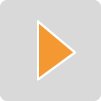
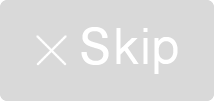
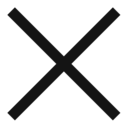
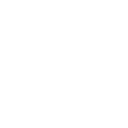
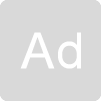
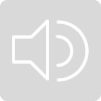
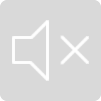

In [19]:
driver.page_source

In [25]:
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager

# Case 1 - Download the driver using ChromeDriverManager
#driver = webdriver.Chrome(ChromeDriverManager().install())
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
#driver.maximize_window()
url = 'https://peru21.pe/lima/peru21-epaper-una-experiencia-sin-limites-noticia/'
driver.get(url)

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/442858013.py:6: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')


In [26]:
driver.page_source

'<html itemscope="" itemtype="http://schema.org/WebPage" lang="es"><head><meta charset="utf-8"><meta http-equiv="X-UA-Compatible" content="IE=edge"><meta name="viewport" content="width=device-width, initial-scale=1"><meta name="lang" content="es"><meta name="deployment" content="3063"><meta name="resource-type" content="document"><meta content="global" name="distribution"><meta name="robots" content="index, follow"><meta name="robots" content="max-image-preview:large"><meta name="googlebot" content="index, follow"><meta name="author" content="Peru21"><meta name="DC.title" lang="es" content="Perú21 ePaper: una experiencia sin límites | LIMA | PERU21"><meta name="DC.description" lang="es" content="Conoce la historia y los beneficios de un periódico digital que es diariamentente enriquecido por periodistas con material multimedia y documentación exclusiva."><meta name="DC.subject" lang="es" content="Noticias, Peru21, Peru, Mundo, Deportes, Internacional, Tecnologia, Diario, Cultura, Cienc

In [25]:
# Refresh the page - 
driver.refresh() #reload or refresh the browser

In [ ]:
# # Case 1 - Download the driver using ChromeDriverManager
# service = Service(ChromeDriverManager().install())

# driver = webdriver.Chrome(service=service)

# driver.maximize_window()

In [ ]:
# Case 1 - Download the driver using ChromeDriverManager
service = Service(ChromeDriverManager().install())

driver = webdriver.Chrome(service=service)

driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

In [24]:
# driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# service = Service(executable_path='chromedriver.exe')

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

url_2 = "https://larepublica.pe/politica/2024/01/15/audios-revelan-que-equipo-fiscal-del-caso-cuellos-blancos-armo-plan-contra-harvey-colchado-ministerio-publico-561360"
driver.get( url_2 )

driver.back()

In [30]:
# driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# service = Service(executable_path='chromedriver.exe')

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )
time.sleep(3)

url_2 = "https://www.google.com/"
driver.get( url_2 )
time.sleep(3)

driver.back()

In [29]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )
time.sleep(3)

url_2 = "https://elcomercio.pe/deporte-total/futbol-peruano/noche-blanquiazul-en-vivo-alianza-lima-once-caldas-hoy-dsports-liga-1-max-minuto-a-minuto-desde-el-estadio-nacional-lbposting-noticia/"
driver.get( url_2 )
time.sleep(9)

driver.back()

In [28]:
driver.close()

In [31]:
driver.quit()

![Quite and Close](Images/quite_close.png)

In [40]:
type(driver)

selenium.webdriver.chrome.webdriver.WebDriver

`driver` is an `selenium.webdriver.chrome.webdriver.WebDriver` object. This object has some attributes that will help us to navigate on the web.

Now, you can see in the driver that we are in [this link](https://www.convocatoriascas.com/).

# Extra - Best Practices before working

1. Maximize the browser

In [32]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

#driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')

url = 'https://www.kaspersky.com/resource-center/definitions/cookies'
driver.get( url )

driver.maximize_window()

2. Set the Browser Zoom Level to 100 percent

In [33]:
driver.execute_script("document.body.style.zoom='100%'")

### 7.4.1. HTML
HTML stands for HyperText Markup Language. You can deduce that it’s a language for creating web pages. It’s not a programming language like Python or Java, but it’s a markup language. It describes the elements of a page through tags characterized by angle brackets.

1. The document always begins and ends using `<html>` and `</html>`.
2. `<body></body>` constitutes the visible part of HTML document.
3. `<h1>` to `<h3>` tags are defined for the headings.

#### 7.4.1.1. HTML Headings
HTML headings are defined with the `<h1>` to `<h6>` tags.
`<h1>` defines the most important heading. `<h6>` defines the least important heading.

We can use text cells since markdown reads html tags.

<h1>This is heading 1</h1>
<h2>This is heading 2</h2>
<h3>This is heading 3</h3>

#### 7.4.1.2. HTML Paragraphs
HTML paragraphs are defined with the `<p>` tag.
`<br>` tag is similar to `"\n"`.

<html>
<br>
<p>My first paragraph.</p> <br>
<p>This is another paragraph for this text cell.</p>
<html>

#### 7.4.1.3. HTML Links
HTML links are defined with the <a> tag:

<a href="http://bayes.cs.ucla.edu/jp_home.html">This is a link for Judea Pearl Website</a>

#### 7.4.1.3. Unordered HTML List
An unordered list starts with the `<ul>` tag. Each list item starts with the `<li>` tag.

<ul>
  <li>Coffee</li>
  <li>Tea</li>
  <li>Milk</li>
</ul>

#### 7.4.1.4. Ordered HTML List
An ordered list starts with the `<ol>` tag. Each list item starts with the `<li>` tag.

<ol>
  <li>Coffee</li>
  <li>Tea</li>
  <li>Milk</li>
</ol>

#### 7.4.1.4. HTML Tables

A table in HTML consists of table cells inside rows and columns. Each table cell is defined by a `<td>` and a `</td>` tag. Each table row starts with a `<tr>` and end with a `</tr>` tag.

<table>
  <tr>
    <th>Manager</th>
    <th>Club</th>
    <th>Nationality</th>
  </tr>
  <tr>
    <td>Mikel Arteta</td>
    <td>Arsenal</td>
    <td>Spain</td>
  </tr>
  <tr>
    <td>Thomas Tuchel</td>
    <td>Chelsea</td>
    <td>Germany</td>
  </tr>
</table>

#### 7.4.1.5. HTML Iframes

An HTML iframe is used to display a web page within a web page.


<!DOCTYPE html>
<html>
  
<head>
    <title>HTML iframe src Attribute</title>
</head>
  
<body style="text-align: center">
    <h1>Diploma</h1>
    <h2>HTML iframe</h2>
    <iframe>
          
        <!DOCTYPE html>
        <html>

        <head>
            <title>New html</title>
        </head>

        <body style="text-align: center">
            <h1>Diploma2</h1>
            <h2>HTML iframe</h2>
            <iframe>

            </iframe>
        </body>

        </html>
    </iframe>
</body>
  
</html>

#### 7.4.1.6. HTML Tags - Key

|Tag|Description|
|---|---|
|`<h1>` to `<h6>`|	Defines HTML headings|
|`<ul>`|	Defines an unordered list|
|`<ol>`|	Defines an ordered list|
|`<p>`|	Defines a paragraph|
|`<a>`|	It is termed as anchor tag and it creates a hyperlink or link.|
|`<div>`|	It defines a division or section within HTML document.|
|`<strong>`|	It is used to define important text.|
|`<table>`|	It is used to present data in tabular form or to create a table within HTML document.|
|`<td>`|	It is used to define cells of an HTML table which contains table data|
|`<iframe>`|	Defines an inline frame|

### 7.4. Identifying elements in a web page

To identify elements of a webpage, we need to inspect the webpage. Open the driver and press `Ctrl`+ `Shift` + `I`.

#### One Element
|Method|Description|
|---|---|
|find_element_by_id| Use id.|
|find_element_by_name| Use name.|
|find_element_by_xpath| Use Xpath.|
|find_element_by_tag_name| Use HTML tag.|
|find_element_by_class_name| Use class name.|
|find_element_by_css_selector| Use css selector.|

#### One Element - New Documentation

* find_element(By.ID, "id")
* find_element(By.NAME, "name")
* find_element(By.XPATH, "xpath")
* find_element(By.LINK_TEXT, "link text")
* find_element(By.PARTIAL_LINK_TEXT, "partial link text")
* find_element(By.TAG_NAME, "tag name")
* find_element(By.CLASS_NAME, "class name")
* find_element(By.CSS_SELECTOR, "css selector")


#### Multiple  elements
|Method|Description|
|---|---|
|find_elements_by_id| Use id.|
|find_elements_by_name| Use name.|
|find_elements_by_xpath| Use Xpath.|
|find_elements_by_tag_name| Use HTML tag.|
|find_elements_by_class_name| Use class name.|
|find_elements_by_css_selector| Use css selector.|

#### Multiple  elements - New Documentation

* find_element(By.ID, "id")
* find_element(By.NAME, "name")
* find_element(By.XPATH, "xpath")
* find_element(By.LINK_TEXT, "link text")
* find_element(By.PARTIAL_LINK_TEXT, "partial link text")
* find_element(By.TAG_NAME, "tag name")
* find_element(By.CLASS_NAME, "class name")
* find_element(By.CSS_SELECTOR, "css selector")


### 7.4.1. Xpath
XPath in Selenium is an XML path used for navigation through the HTML structure of the page. It is a syntax or language for finding any element on a web page using XML path expression.

The basic format of XPath in selenium is explained below with screen shot.
<img src="../_images/x_path.png">

**DO NOT COMPLICATE!**
Finding the XPath of a element:
1. Go to the element
2. Right click
3. Inspect - You may have to do it twice.
4. Go to the selected line
5. Right click
7. Copy 
8. Copy Full Xpath

**Example**

We are going to select `Economistas` option and make a click. Use `find_element_by_xpath` and click.

In [50]:
from selenium.webdriver.common.by import By

In [42]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

# resumen_general = driver.find_element( By.XPATH  , '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]')
# resumen_general.click()
#time.sleep(3)

In [46]:
resumen_general = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]')
resumen_general.click()

In [40]:
resumen_general = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]')
resumen_general.click()

In [ ]:
# /html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div

In [ ]:
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[2]/div/div/a/div[2]
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[3]/div/div/a/div[2]


In [ ]:
# resumen general
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div
# elecciones presidenciales
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[2]/div/div/a/div[2]

In [ ]:
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div
/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[2]/div/div/a/div[2]


In [42]:
resumen_general = driver.find_element( By.XPATH  , '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]')
resumen_general.click()

In [45]:
resumen_general = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div')
resumen_general.click()

In [ ]:
#mapdiv > div > div.amcharts-chart-div > svg > g:nth-child(8) > g > g:nth-child(1) > path:nth-child(36)

In [37]:
resumen_general = driver.find_element(By.XPATH,'/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[1]/img')
resumen_general.click()

In [47]:
driver.find_element(By.ID, 'select_ambito').click()

In [48]:
driver.find_element(By.NAME, 'cod_ambito').click()

In [50]:
# Best practices
driver.find_element_by_id('select_ambito').click

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/1378342553.py:2: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_id('select_ambito').click


<bound method WebElement.click of <selenium.webdriver.remote.webelement.WebElement (session="1a13ad624adb1cf7a31de2819cfb2853", element="CC672BADD6034D8F6E5A6D676105A73F_element_3682")>>

In [60]:
# driver.find_element_by_name('cod_ambito').click()
#driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div/select')

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/1327973677.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_name('cod_ambito').click()


In [44]:
# driver.find_element_by_class_name('select_ubigeo')

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/3486675539.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_class_name('select_ubigeo')


<selenium.webdriver.remote.webelement.WebElement (session="fcb117569a03c401035e92fbc09659db", element="FA2D5037E60912FE13DFE1E09C17F29E_element_11974")>

In [46]:
# searchBox = driver.find_element_by_id('select_ambito')
# searchBox = driver.find_element_by_xpath('//*[@id="select_ambito"]')
# searchBox = driver.find_element_by_css_selector('#select_ambito')

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/2823056965.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  searchBox = driver.find_element_by_id('select_ambito')


![Web Element](Images/Web_Elementpng.png)

In [49]:
searchBox.get_attribute('value')

'T'

In [48]:
searchBox.get_attribute('value')

'T'

In [50]:
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')

url = 'https://resultadoshistorico.onpe.gob.pe/EG2021/'
driver.get( url )

driver.maximize_window()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/892230165.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')


In [51]:
driver.find_element_by_xpath("/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[1]/img").click()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/1411387364.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_xpath("/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[1]/img").click()


In [53]:
searchBox = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')
searchBox.click()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/1563849843.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  searchBox = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')


In [56]:
searchBox = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')
searchBox.text

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/792330971.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  searchBox = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')


'PERÚ'

In [41]:
searchBox = driver.find_element_by_id('select_ambito')
searchBox

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_4352/2800196250.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  searchBox = driver.find_element_by_id('select_ambito')


<selenium.webdriver.remote.webelement.WebElement (session="b5ca8d1ebed563e3c66a5bd8dcd59bc6", element="F4712B94759471922218DCBC330F7E1A_element_91")>

**Suggestion** <br>
We do not recomend to use `tag` at first time since most web pages use nested tags and it is difficult to define a element using HTML tag. However, it is great to find elements that is inside another located element in the web. Let's see the example.

# EXAMPLE USING ONPE WEBPAGE

## Example to extract Table

In [53]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )
driver.maximize_window()

In [54]:
xpath = '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[2]/div/div/a/div[2]'
resumen_general = driver.find_element(By.XPATH, xpath)
resumen_general.click()

In [56]:
xpath_peru = '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[1]/select/option[2]'
resumen_general = driver.find_element(By.XPATH, xpath_peru)
resumen_general.click()

# ELECCIONES REGIONALES MUNICIPALES

In [66]:
# pip install undetected-chromedriver

In [67]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

driver = uc.Chrome()
driver.get("https://resultadoshistorico.onpe.gob.pe/ERM2022/Home")

# # Wait for dynamic content
# WebDriverWait(driver, 30).until(
#     EC.presence_of_element_located((By.CSS_SELECTOR, "table, .result-data"))
# )

# print(driver.page_source)
# driver.quit()


In [60]:
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)

url_1 = "https://resultadoshistorico.onpe.gob.pe/ERM2022/Home"
driver.get( url_1 )
driver.maximize_window()

In [68]:
xpath_regionales = '/html/body/onpe-root/onpe-home-onpe/div/div/div/div[2]/a/div'
eleccion_regionales = driver.find_element(By.XPATH, xpath_regionales)
eleccion_regionales.click()

In [69]:
xpath_lima = '/html/body/onpe-root/onpe-layout-container/onpe-onpe-ereg-regv/div/div[1]/div[1]/div[1]/select/option[15]'
eleccion_lima = driver.find_element(By.XPATH, xpath_lima)
eleccion_lima.click()

In [74]:
xpath_table = '/html/body/onpe-root/onpe-layout-container/onpe-onpe-ereg-regv/div/div[2]/div/div[2]/div[2]/div[3]/div/table'
table_path = driver.find_element(By.XPATH, xpath_table)

table_path.get_attribute('outerHTML')
table_html = table_path.get_attribute('outerHTML')
table_html

table = pd.read_html(table_html)[0]
table 

C:\Users\Alexander\AppData\Local\Temp\ipykernel_38776\2633178464.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(table_html)[0]


,Organización política,Organización política.1,Total,% Votos válidos,% Votos emitidos
0,NaN,PATRIA JOVEN,100226,19.827 %,16.281 %
1,NaN,MOVIMIENTO REGIONAL UNIDAD CIVICA LIMA,137052,27.112 %,22.263 %
2,NaN,CONCERTACION PARA EL DESARROLLO REGIONAL - LIMA,71969,14.237 %,11.691 %
3,NaN,PARTIDO FRENTE DE LA ESPERANZA 2021,14637,2.896 %,2.378 %
4,NaN,RENOVACION POPULAR,49997,9.891 %,8.122 %
5,NaN,ALIANZA PARA EL PROGRESO,33266,6.581 %,5.404 %
6,NaN,AVANZA PAIS - PARTIDO DE INTEGRACION SOCIAL,16674,3.299 %,2.709 %
7,NaN,PARTIDO POLITICO NACIONAL PERU LIBRE,16710,3.306 %,2.714 %
8,NaN,PARTIDO DEMOCRATICO SOMOS PERU,64964,12.852 %,10.553 %
9,NaN,TOTAL DE VOTOS VÁLIDOS,505495,100.000 %,82.114 %


In [ ]:
table_html = table_path.get_attribute( 'innerHTML' )
table_html

In [80]:
import os 
import requests 
# Find all img elements inside the table tbody
images = driver.find_elements(By.XPATH,
    "//onpe-onpe-ereg-regv//table/tbody//img"
)

print(f"Found {len(images)} images")

# Create output folder
os.makedirs("downloaded_images", exist_ok=True)

Found 9 images


In [81]:
# Download each image
for i, img in enumerate(images):
    src = img.get_attribute("src")
    if not src:
        continue

    # Handle base64 images
    if src.startswith("data:image"):
        import base64
        # Format: data:image/png;base64,iVBOR...
        header, data = src.split(",", 1)
        ext = header.split("/")[1].split(";")[0]  # png, jpeg, etc.
        with open(f"downloaded_images/image_{i}.{ext}", "wb") as f:
            f.write(base64.b64decode(data))
    else:
        # Regular URL - download it
        response = requests.get(src, stream=True)
        ext = src.split(".")[-1].split("?")[0] or "png"
        with open(f"downloaded_images/image_{i}.{ext}", "wb") as f:
            f.write(response.content)

    print(f"Saved image_{i}")

Saved image_0
Saved image_1
Saved image_2
Saved image_3
Saved image_4
Saved image_5
Saved image_6
Saved image_7
Saved image_8


In [83]:
for i, img in enumerate(images):
    img.screenshot(f"downloaded_images/image_{i}.png")
    print(f"Saved image_{i}.png")


Saved image_0.png
Saved image_1.png
Saved image_2.png
Saved image_3.png
Saved image_4.png
Saved image_5.png
Saved image_6.png
Saved image_7.png
Saved image_8.png


In [50]:
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div').click()

In [51]:
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-menu/div/nav/div/div/div[2]/div/div[2]/a').click()

In [52]:
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div/select/option[2]').click()

In [57]:
table_path = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]')

In [58]:
table_html = table_path.get_attribute( 'innerHTML' )
table_html

'<div _ngcontent-ets-c101="" class="table-wrap"><table _ngcontent-ets-c101="" width="100%" id="table1" class="main-table table table-striped tabla_resultado"><tr _ngcontent-ets-c101=""><th _ngcontent-ets-c101="" align="center" colspan="6" class="fixed-side">TOTAL DE VOTOS</th></tr><tr _ngcontent-ets-c101=""><td _ngcontent-ets-c101="" align="center" colspan="3" class="titulo_td fixed-side">ORGANIZACIONES POLÍTICAS</td><td _ngcontent-ets-c101="" align="center" class="titulo_td fixed-side">TOTAL</td><td _ngcontent-ets-c101="" align="center" class="titulo_td fixed-side">%VÁLIDOS</td><td _ngcontent-ets-c101="" align="center" class="titulo_td fixed-side">%EMITIDOS</td></tr><!----></table></div>'

In [59]:
table = pd.read_html( table_html )
table[0]

C:\Users\Alexander\AppData\Local\Temp\ipykernel_38776\1242046661.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html( table_html )


,TOTAL DE VOTOS,TOTAL DE VOTOS.1,TOTAL DE VOTOS.2,TOTAL DE VOTOS.3,TOTAL DE VOTOS.4,TOTAL DE VOTOS.5
0,ORGANIZACIONES POLÍTICAS,ORGANIZACIONES POLÍTICAS,ORGANIZACIONES POLÍTICAS,TOTAL,%VÁLIDOS,%EMITIDOS


In [75]:
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
driver.maximize_window()

url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div').click()
time.sleep(2)
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-menu/div/nav/div/div/div[2]/div/div[2]/a').click()
time.sleep(2)
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[1]/select/option[2]').click()
time.sleep(2)

table_path = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]')

table_html = table_path.get_attribute( 'innerHTML' )

table = pd.read_html( table_html )
table[0]

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/151453635.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')


,TOTAL DE VOTOS,TOTAL DE VOTOS.1,TOTAL DE VOTOS.2,TOTAL DE VOTOS.3,TOTAL DE VOTOS.4,TOTAL DE VOTOS.5
0,ORGANIZACIONES POLÍTICAS,ORGANIZACIONES POLÍTICAS,ORGANIZACIONES POLÍTICAS,TOTAL,%VÁLIDOS,%EMITIDOS
1,NaN,NaN,PARTIDO NACIONALISTA PERUANO,228955,1.608%,1.309%
2,NaN,NaN,"EL FRENTE AMPLIO POR JUSTICIA, VIDA Y LIBERTAD",64217,0.451%,0.367%
3,NaN,NaN,PARTIDO MORADO,319176,2.242%,1.825%
4,NaN,NaN,PERU PATRIA SEGURA,54341,0.382%,0.311%
5,NaN,NaN,VICTORIA NACIONAL,802957,5.639%,4.592%
6,NaN,NaN,ACCION POPULAR,1294681,9.092%,7.404%
7,NaN,NaN,AVANZA PAIS - PARTIDO DE INTEGRACION SOCIAL,1652682,11.607%,9.452%
8,NaN,NaN,PODEMOS PERU,808559,5.678%,4.624%
9,NaN,NaN,JUNTOS POR EL PERU,1111407,7.805%,6.356%


In [76]:
# Clean Table
row_new_columns = table[ 0 ].iloc[ 0 , 2: ]

clean_columns = row_new_columns \
                      .str.replace( " ", "_") \
                      .str.lower().str.replace( "%", "share_") \
                      .apply( lambda x : unidecode.unidecode( x ) ) \
                      .tolist()

# Selecting specific columns
table_clean = table[0].iloc[ 1:, 2: ].copy()

# rename columns
table_clean.columns = clean_columns

In [77]:
table_clean

,organizaciones_politicas,total,share_validos,share_emitidos
1,PARTIDO NACIONALISTA PERUANO,228955,1.608%,1.309%
2,"EL FRENTE AMPLIO POR JUSTICIA, VIDA Y LIBERTAD",64217,0.451%,0.367%
3,PARTIDO MORADO,319176,2.242%,1.825%
4,PERU PATRIA SEGURA,54341,0.382%,0.311%
5,VICTORIA NACIONAL,802957,5.639%,4.592%
6,ACCION POPULAR,1294681,9.092%,7.404%
7,AVANZA PAIS - PARTIDO DE INTEGRACION SOCIAL,1652682,11.607%,9.452%
8,PODEMOS PERU,808559,5.678%,4.624%
9,JUNTOS POR EL PERU,1111407,7.805%,6.356%
10,PARTIDO POPULAR CRISTIANO - PPC,282007,1.981%,1.613%


In [72]:
table_clean.to_csv("C:/Users/Alexander/Documents/GitHub/MediaLab_Summer_Python/Lecture_7/output/elecciones_peru_2021.csv")

## [First Round](https://resultadoshistorico.onpe.gob.pe/EG2021/ResumenGeneral/10/T)

In [42]:
# pip install lxml
# pip install lxmunidecodel

In [43]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver import ActionChains
import pandas as pd
import numpy as np
import os
import time
import re
import unidecode
import time 
from selenium.webdriver.support.ui import Select
from webdriver_manager.chrome import ChromeDriverManager

# Driver Path Address

In [44]:
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# Maximize window
driver.maximize_window()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_4352/523775411.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')


# Extracting all tables

In [57]:
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# Maximize window
driver.maximize_window()

# go to the link
url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

resumen_general = driver.find_element_by_xpath('/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[1]/img')
resumen_general.click()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/2332946352.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/2332946352.py:9: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  resumen_general = driver.find_element_by_xpath('/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[1]/img')


In [58]:
presidential = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[2]/ul/li[1]/a')
presidential.click()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/2079164939.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  presidential = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[2]/ul/li[1]/a')


In [61]:
opt_peru = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')
opt_peru.click()

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/3582292250.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opt_peru = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select/option[2]')


## Pesidential results

In [48]:
# presidential = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-menu/div/nav/div/div/div[2]/div/div[2]/a/span')
# presidential.click

In [49]:
# # presidential section
# presidential = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-menu/div/nav/div/div/div[2]/div/div[2]/a" )
# presidential.click()

### Get all elements from all options

In [50]:
# scope = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div/select" )
# scope.click()

In [70]:
#Actualización de las funciones para usar objetos con selenium
regiones = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select')
regiones

<selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_6028")>

In [69]:
driver.find_element(By.XPATH, "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select/option[2]").text

'AMAZONAS'

In [75]:
#Actualización de las funciones para usar objetos con selenium
regiones = driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select')
regiones.find_elements(By.TAG_NAME, "option")[1].text

'AMAZONAS'

In [52]:
regiones.find_elements(By.TAG_NAME,"option")[1].text

'AMAZONAS'

In [57]:
scope_options = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select')
scope_options.find_elements_by_tag_name("option")[2].text

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_4352/2865713082.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  scope_options = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select')
C:\Users\Alexander\anaconda3\lib\site-packages\selenium\webdriver\remote\webelement.py:359: UserWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  warnings.warn("find_elements_by_* commands are deprecated. Please use find_elements() instead")


'EXTRANJERO'

In [59]:
scope_options = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select')

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_4352/939183077.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  scope_options = driver.find_element_by_xpath('/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select')


In [62]:
scope_options.find_elements_by_tag_name("option")[0].text
scope_options.find_elements_by_tag_name("option")[1].text
scope_options.find_elements_by_tag_name("option")[2].text

'EXTRANJERO'

In [77]:
scope = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select" )
scope

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/457926441.py:1: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  scope = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[1]/select" )


<selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_7852")>

In [81]:
scope.find_elements_by_tag_name("option")[2].text

'EXTRANJERO'

In [64]:
scope_options = scope.find_elements_by_tag_name("option")

In [65]:
scope_options

[<selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_371")>,
 <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_376")>,
 <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_380")>]

In [66]:
dict_scope_options = { i.text : i for i in scope_options }
dict_scope_options

{'TODOS': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_371")>,
 'PERÚ': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_376")>,
 'EXTRANJERO': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_380")>}

In [67]:
# There are three options
dict_scope_options.keys()
dict_scope_options

{'TODOS': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_371")>,
 'PERÚ': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_376")>,
 'EXTRANJERO': <selenium.webdriver.remote.webelement.WebElement (session="7044b58859814a98da64965ce17db995", element="98CC869DA3BC59F8EC849A0A10F8CCE8_element_380")>}

In [68]:
# We click on Peru
dict_scope_options['PERÚ'].click()

We have to be careful since everytime we make a click, the url changes.

### Loop over all departments

In [91]:
from selenium.webdriver.support.ui import Select  # Import Select class

In [95]:
# Store all_tables
all_tables = {}

dept_0 = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select" )
dept_0

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/3847548577.py:4: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dept_0 = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select" )


<selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_6028")>

In [99]:
# All selenium objects in department select
dpt = Select( dept_0 )
#dpt.options[15].text

In [100]:
dpt.options

[<selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4358")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4359")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4360")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4361")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4362")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844d1f13ad43e1035b2", element="41616776DD4C61A8DC4C3BA36E17EA26_element_4363")>,
 <selenium.webdriver.remote.webelement.WebElement (session="150dbc982fccd844

In [101]:
# Get number of total options
num_prov_options = len( dpt.options )
num_prov_options

26

In [102]:
# we can loop over all departments
# for dpt_idx in range( num_prov_options ):
# but it will take too much time
# We are going to do it over two departments
for dpt_idx in range( num_prov_options ):
    
    # Get again all departments since HTML is refreshing
    # all elements
    # Click on one specific department
    dpt = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select" ) )
    department = dpt.options[ dpt_idx ]
    
    # Get departmant name
    dpt_name = department.text
    print(dpt_name)

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_23860/1015677902.py:10: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dpt = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-rgen-rsgr/div/div[2]/div[1]/div[1]/div/div/div[2]/select" ) )


--TODOS--
AMAZONAS
ANCASH
APURIMAC
AREQUIPA
AYACUCHO
CAJAMARCA
CALLAO
CUSCO
HUANCAVELICA
HUANUCO
ICA
JUNIN
LA LIBERTAD
LAMBAYEQUE
LIMA
LORETO
MADRE DE DIOS
MOQUEGUA
PASCO
PIURA
PUNO
SAN MARTIN
TACNA
TUMBES
UCAYALI


# Dynamic Pages

In [ ]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)

driver.get('https://www.legacy.com/obituaries/legacy/obituary-search.aspx?isnew=1&affiliateId=0&stateid=17')

In [88]:
driver.maximize_window()

In [89]:
name = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[3]/div/div[1]/input[1]')
name.send_keys("Maria")

In [90]:
lastname = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[3]/div/div[1]/input[2]')
lastname.send_keys("Brown")

In [93]:
date_range = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[1]/select/option[10]')
date_range.click()

In [94]:
date_begin = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[3]/div[2]/input')
date_begin.send_keys("01/01/2000")

In [95]:
date_begin = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[3]/div[4]/input')
date_begin.send_keys("01/01/2023")

In [91]:
search = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[5]/div/div[2]/a')
search.click()

In [96]:
service = Service(executable_path="chromedriver-win64/chromedriver.exe")
driver = webdriver.Chrome(service=service)

driver.get('https://www.legacy.com/obituaries/legacy/obituary-search.aspx?isnew=1&affiliateId=0&stateid=17')

driver.maximize_window()

name = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[3]/div/div[1]/input[1]')
name.send_keys("Maria")

lastname = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[3]/div/div[1]/input[2]')
lastname.send_keys("Brown")

date_range = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[1]/select/option[10]')
date_range.click()

date_begin = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[3]/div[2]/input')
date_begin.send_keys("01/01/2000")

date_begin = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[1]/div[2]/div[3]/div[4]/input')
date_begin.send_keys("01/01/2023")

search = driver.find_element(By.XPATH, '/html/body/div[2]/div[2]/div[2]/form/div[3]/div[1]/div[1]/div/div/div[1]/div[2]/div[5]/div/div[2]/a')
search.click()


In [84]:

driver = webdriver.Chrome( ChromeDriverManager().install() )
# Maximize window
driver.maximize_window()
driver.get('https://www.legacy.com/obituaries/legacy/obituary-search.aspx?isnew=1&affiliateId=0&stateid=17')

# range of death
driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_ddlSearchRange"]/option[10]').click()


death_begin = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtStartDate"]')
death_begin.send_keys('10/10/1994')

death_end = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtEndDate"]')    
death_end.send_keys('10/10/2005')

# type the Firstname 
keyword = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtFirstName"]')
keyword.send_keys('robert')

# type the Lastname 
keyword = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtLastName"]')
keyword.send_keys('brown')

# type the Title 
keyword = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtKeyword"]')
keyword.send_keys('professor')

 # Set the state of last residence
driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_ddlCountry"]/option[11]').click()
        
# Send information
driver.find_element_by_xpath('//*[@id="lnkSearch"]').click()




C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/2320181688.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome( ChromeDriverManager().install() )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/2320181688.py:7: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_ddlSearchRange"]/option[10]').click()
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/2320181688.py:10: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  death_begin = driver.find_element_by_xpath('//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_txtStartDate"]')
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38996/2320181688.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use fin

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"xpath","selector":"//*[@id="ctl00_ctl00_ContentPlaceHolder1_ContentPlaceHolder1_uxSearchWideControl_ddlCountry"]/option[11]"}
  (Session info: chrome=120.0.6099.217)
Stacktrace:
	GetHandleVerifier [0x00D56EE3+174339]
	(No symbol) [0x00C80A51]
	(No symbol) [0x00996FF6]
	(No symbol) [0x009C9876]
	(No symbol) [0x009C9C2C]
	(No symbol) [0x009FBD42]
	(No symbol) [0x009E7054]
	(No symbol) [0x009FA104]
	(No symbol) [0x009E6DA6]
	(No symbol) [0x009C1034]
	(No symbol) [0x009C1F8D]
	GetHandleVerifier [0x00DF4B1C+820540]
	sqlite3_dbdata_init [0x00EB53EE+653550]
	sqlite3_dbdata_init [0x00EB4E09+652041]
	sqlite3_dbdata_init [0x00EA97CC+605388]
	sqlite3_dbdata_init [0x00EB5D9B+656027]
	(No symbol) [0x00C8FE6C]
	(No symbol) [0x00C883B8]
	(No symbol) [0x00C884DD]
	(No symbol) [0x00C75818]
	BaseThreadInitThunk [0x76F3FCC9+25]
	RtlGetAppContainerNamedObjectPath [0x77DB7C6E+286]
	RtlGetAppContainerNamedObjectPath [0x77

## Final Example - ONPE

In [86]:
# Store all_tables
all_tables = {}

driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# Maximize window
driver.maximize_window()

# go to the link
url_1 = "https://resultadoshistorico.onpe.gob.pe/EG2021/"
driver.get( url_1 )

driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-home-onpe/div[1]/div/div/div/div[2]/div[1]/div/div/a/div[2]/div').click()
time.sleep(2)
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-menu/div/nav/div/div/div[2]/div/div[2]/a').click()
time.sleep(2)
driver.find_element(By.XPATH, '/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[1]/select/option[2]').click()
time.sleep(2)

# we can loop over all departments
# for dpt_idx in range( num_prov_options ):
# but it will take too much time
# We are going to do it over two departments
for dpt_idx in range( 2 ):
    
    # Get again all departments since HTML is refreshing
    # all elements
    # Click on one specific department
    dpt = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[2]/select" ) )
    department = dpt.options[ dpt_idx ]
    
    # Get departmant name
    dpt_name = department.text
    
    # We select a different department name
    if dpt_name != "--TODOS--" :
        
        # click on department
        department.click()
        
        # Get all elements of province
        prov = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[3]/select" ) )
        num_prov_options = len( prov.options )
        
        for prov_idx in range( num_prov_options ):
            
            # Get again all districts since HTML is refreshing
            # all elements
            prov = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[3]/select" ) )
            province = prov.options[ prov_idx ]
                
            # Get province name
            prov_name = province.text
            
            if prov_name != "--TODOS--" :
                
                # click on province
                province.click()
                
                # Get all elements from district
                dist = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[4]/select" ) )
                num_dist_options = len( dist.options )
                
                for dist_idx in range( num_dist_options ):
                    
                    # Get again all districts since HTML is refreshing
                    # all elements
                    dist = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[4]/select" ) )
                    district = dist.options[ dist_idx ]
                    
                    # Get district name
                    dist_name = district.text
                    
                    if dist_name != "-- SELECCIONE --" :
                        
                        # click on district
                        district.click()
                        
                        # Get UBIGEO
                        ubigeo = driver.current_url.split("/")[ -1 ]
                        
                        ## Get table of presidential votes
                        # Get html at this point
                        table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
                        table_html = table_path.get_attribute( 'innerHTML' )
                        # Read the table using pandas
                        table = pd.read_html( table_html )
                        
                        # Cleaning tables
                        row_new_columns = table[ 0 ].iloc[ 0 , 2: ]
                        clean_columns = row_new_columns \
                                              .str.replace( " ", "_") \
                                              .str.lower().str.replace( "%", "share_") \
                                              .apply( lambda x : unidecode.unidecode( x ) ) \
                                              .tolist()
                        
                        # Selecting specific columns
                        table_clean = table[0].iloc[ 1:, 2: ].copy()
                        
                        # rename columns
                        table_clean.columns = clean_columns
                        
                        # New values to columns 
                        table_clean[ 'department' ] = dpt_name
                        table_clean[ 'province' ]   = prov_name
                        table_clean[ 'district' ]   = dist_name
                        table_clean[ 'ubigeo' ]     = ubigeo
                        
                        # store tables
                        all_tables[ ubigeo ] = table_clean

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:4: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:28: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dpt = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[2]/select" ) )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:41: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  prov = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[3]/select" ) )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:48: DeprecationWarning: f

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:67: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dist = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[4]/select" ) )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykerne

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:67: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dist = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[4]/select" ) )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykerne

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:67: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  dist = Select( driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[3]/div[1]/div[1]/div/div/div[4]/select" ) )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/4045826796.py:83: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  table_path = driver.find_element_by_xpath( "/html/body/onpe-root/onpe-layout-container/onpe-onpe-epres-re/div[1]/div[4]/div[1]/div[3]/div" )
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykerne

StaleElementReferenceException: Message: stale element reference: stale element not found
  (Session info: chrome=120.0.6099.217)
Stacktrace:
	GetHandleVerifier [0x00007FF7544A2142+3514994]
	(No symbol) [0x00007FF7540C0CE2]
	(No symbol) [0x00007FF753F676AA]
	(No symbol) [0x00007FF753F6CFC0]
	(No symbol) [0x00007FF753F6F38F]
	(No symbol) [0x00007FF753F6F480]
	(No symbol) [0x00007FF753FB5ADC]
	(No symbol) [0x00007FF753FA732B]
	(No symbol) [0x00007FF753FD5FEA]
	(No symbol) [0x00007FF753FA63B6]
	(No symbol) [0x00007FF753FD6490]
	(No symbol) [0x00007FF753FF28F6]
	(No symbol) [0x00007FF753FD5D93]
	(No symbol) [0x00007FF753FA4BDC]
	(No symbol) [0x00007FF753FA5C64]
	GetHandleVerifier [0x00007FF7544CE16B+3695259]
	GetHandleVerifier [0x00007FF754526737+4057191]
	GetHandleVerifier [0x00007FF75451E4E3+4023827]
	GetHandleVerifier [0x00007FF7541F04F9+689705]
	(No symbol) [0x00007FF7540CC048]
	(No symbol) [0x00007FF7540C8044]
	(No symbol) [0x00007FF7540C81C9]
	(No symbol) [0x00007FF7540B88C4]
	BaseTh

In [12]:
final_data = pd.concat( all_tables.values() ).reset_index( drop = True )

In [15]:
final_data.to_excel( r'example_round.xlsx' , index = False )

## Ejemplo Gisella

In [101]:
driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
# Maximize window
driver.maximize_window()

# go to the link
url_1 = "https://rpp.pe/noticias/pedro-castillo"
driver.get( url_1 )

# Loop to scroll down
try:
    while True:
        # Scroll down
        driver.find_element_by_tag_name('body').send_keys(Keys.END)

        # Wait for the page to load
        time.sleep(3)

        # Check if the "see more" button is present, if not, break the loop
        if not driver.find_elements_by_xpath("/html/body/div[4]/main/div[3]/div[1]/div[2]/button/span"):
            break
except NoSuchElementException:
    # Handle the case where the element is not found
    pass

C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/947469463.py:1: DeprecationWarning: executable_path has been deprecated, please pass in a Service object
  driver = webdriver.Chrome(executable_path=r'chromedriver-win64/chromedriver.exe')
C:\Users\ALEXAN~1\AppData\Local\Temp/ipykernel_38380/947469463.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  driver.find_element_by_tag_name('body').send_keys(Keys.END)


NameError: name 'NoSuchElementException' is not defined

In [98]:
driver.find_element(By.XPATH, "/html/body/div[4]/main/div[3]/div[1]/div[2]/button/span").click()

In [99]:
driver.find_element(By.XPATH, "/html/body/div[4]/main/div[3]/div[1]/div[2]/button/span").click()